Let's get the data from [FMI Weather](https://en.ilmatieteenlaitos.fi/observation-stations)

This is just a proof of concept that this can work

In [1]:
#!pip install fmiopendata

In [2]:
import pandas as pd
from fmiopendata.wfs import download_stored_query
from datetime import datetime, timedelta
import time

import numpy as np



## Dataset

I have been researching to find the best stations across Finland's cities that would offer the best quality of data, but most of the observation center would either have missing features (`precipitation`, or `wind speed`).

So we will get multiple centers to compensate for this and merge them later into cities

Also we are getting the dataset from **Oulu, Helsinki, Tampere, Rovaniemi, and Vaasa** within the last 30 days, and we are also adding in the `latitude` and `longtitude` for each cities




In [3]:

reliable_stations = {
    "101786": {"city": "Oulu", "name": "Oulu Airport", "lat": 64.93, "lon": 25.35},
    "101004": {"city": "Helsinki", "name": "Helsinki Kumpula", "lat": 60.20, "lon": 24.96},
    "101118": {"city": "Tampere", "name": "Tampere Airport", "lat": 61.41, "lon": 23.60},
    "101124": {"city": "Tampere", "name": "Tampere Harmala", "lat": 61.47, "lon": 23.75},
    "100949": {"city": "Turku", "name": "Turku Artukainen", "lat": 60.51, "lon": 22.20},
    "101933": {"city": "Rovaniemi", "name": "Rovaniemi Airport", "lat": 66.56, "lon": 25.83},
    "101485": {"city": "Vaasa", "name": "Vaasa Klemettila", "lat": 63.09, "lon": 21.65},
    "101462": {"city": "Vaasa", "name": "Vaasa Airport", "lat": 63.05, "lon": 21.76}
}


end_time = datetime.now()
start_time = end_time - timedelta(days=30) 

starttime_str = start_time.strftime('%Y-%m-%dT%H:%M:%SZ')
endtime_str = end_time.strftime('%Y-%m-%dT%H:%M:%SZ')

all_dfs = []

for fmisid, info in reliable_stations.items():
    print(f"Fetching {info['name']} (ID: {fmisid})...")
    try:
        obs = download_stored_query("fmi::observations::weather::hourly::multipointcoverage",
                                    args=[f"fmisid={fmisid}", 
                                          f"starttime={starttime_str}", 
                                          f"endtime={endtime_str}"])
        if obs.data:
            rows = []
            for timestamp, stations in obs.data.items():
                for station_name, parameters in stations.items():
                    # Inject metadata directly into each row
                    row = {
                        'time': timestamp,
                        'city_group': info['city'], # Use this for merging
                        'station_name': info['name'],
                        'lat': info['lat'],
                        'lon': info['lon']
                    }
                    for p_name, p_data in parameters.items():
                        row[p_name.replace(' ', '_').lower()] = p_data.get('value')
                    rows.append(row)
            
            all_dfs.append(pd.DataFrame(rows))
            time.sleep(2) # API Politeness
    except Exception as e:
        print(f"Error at {info['name']}: {e}")

# Create the Raw Master DF
df_raw = pd.concat(all_dfs, ignore_index=True)




Fetching Oulu Airport (ID: 101786)...
Fetching Helsinki Kumpula (ID: 101004)...
Fetching Tampere Airport (ID: 101118)...
Fetching Tampere Harmala (ID: 101124)...
Fetching Turku Artukainen (ID: 100949)...
Fetching Rovaniemi Airport (ID: 101933)...
Fetching Vaasa Klemettila (ID: 101485)...
Fetching Vaasa Airport (ID: 101462)...


In [4]:
df_raw.isnull().sum()

time                                  0
city_group                            0
station_name                          0
lat                                   0
lon                                   0
air_temperature                       0
highest_temperature                   0
lowest_temperature                    0
relative_humidity                     0
wind_speed                          756
maximum_wind_speed                  891
minimum_wind_speed                  891
wind_direction                      921
precipitation_amount               2154
maximum_precipitation_intensity    2158
air_pressure                          0
present_weather_(auto)              718
dtype: int64

In [5]:
df_raw.shape

(5739, 17)

## Preprocessing

So we have about `5739` row with`2158` missing values

So I compensated for this in 2 ways:
- Use multiple centers in one city (and then we can merged the dataset later). I believe that the slight change in distance would not affect the data as a whole
- If there are still missing values, or lack of multiple reliable centers (**Oulu** centers does not have any `precipitation`) we will rely to `present_weather_(auto)` to help us. Since `present_weather_(auto)` give us the current weather status, we can try and deviate the `precipitation` out of this

In [ ]:
# Ensure time is in datetime format
df_raw['time'] = pd.to_datetime(df_raw['time'])

df_raw = df_raw.sort_values(['city_group', 'time'])
df_merged = df_raw.groupby(['city_group', 'time']).first().reset_index()



In [7]:
df_merged['present_weather_(auto)'].describe()

count    3586.000000
mean       33.603179
std        37.718455
min         0.000000
25%         0.000000
50%         0.000000
75%        71.000000
max        87.000000
Name: present_weather_(auto), dtype: float64

In [8]:
# 1. Define the 'Snow Codes' based on your stats
snow_codes = [70, 71, 72, 73, 74, 75, 85, 86]
rain_codes = [60, 61, 62, 63, 64, 65, 80, 81]

# 2. Logic: If precip is missing but we have a snow code, 
# fill with 0.1 (trace) to ensure the model knows 'something' fell.
mask_precip_nan = df_merged['precipitation_amount'].isna()

# Snow logic
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(snow_codes), 'precipitation_amount'] = 0.1

# Rain logic (just in case)
df_merged.loc[mask_precip_nan & df_merged['present_weather_(auto)'].isin(rain_codes), 'precipitation_amount'] = 0.1

# 3. Final Fallback: Everything else becomes 0
df_merged['precipitation_amount'] = df_merged['precipitation_amount'].fillna(0.0)



In [9]:
df_merged.isnull().sum()

city_group                           0
time                                 0
station_name                         0
lat                                  0
lon                                  0
air_temperature                      0
highest_temperature                  0
lowest_temperature                   0
relative_humidity                    0
wind_speed                           2
maximum_wind_speed                   2
minimum_wind_speed                   2
wind_direction                      85
precipitation_amount                 0
maximum_precipitation_intensity    723
air_pressure                         0
present_weather_(auto)             718
dtype: int64

Looks a a lot better and I will just fill in the rest with 0

`Wind_Direction` and `Wind_speed` will be forward filled - using the previous datapoint and fill them into the missing spot, since wind at 8 pm should be somewhat similar with wind at 7 pm

In [10]:
df_merged['wind_speed'] = df_merged.groupby('city_group')['wind_speed'].transform(lambda x: x.interpolate())
df_merged['maximum_wind_speed'] = df_merged.groupby('city_group')['maximum_wind_speed'].transform(lambda x: x.interpolate())
df_merged['minimum_wind_speed'] = df_merged.groupby('city_group')['minimum_wind_speed'].transform(lambda x: x.interpolate())

df_merged['wind_direction'] = df_merged.groupby('city_group')['wind_direction'].ffill()


df_merged['maximum_precipitation_intensity'] = df_merged['maximum_precipitation_intensity'].fillna(0.0)
df_merged['present_weather_(auto)'] = df_merged['present_weather_(auto)'].fillna(0)


df_merged.isnull().sum()

city_group                         0
time                               0
station_name                       0
lat                                0
lon                                0
air_temperature                    0
highest_temperature                0
lowest_temperature                 0
relative_humidity                  0
wind_speed                         0
maximum_wind_speed                 0
minimum_wind_speed                 0
wind_direction                     0
precipitation_amount               0
maximum_precipitation_intensity    0
air_pressure                       0
present_weather_(auto)             0
dtype: int64

In [11]:
df_merged.columns

Index(['city_group', 'time', 'station_name', 'lat', 'lon', 'air_temperature',
       'highest_temperature', 'lowest_temperature', 'relative_humidity',
       'wind_speed', 'maximum_wind_speed', 'minimum_wind_speed',
       'wind_direction', 'precipitation_amount',
       'maximum_precipitation_intensity', 'air_pressure',
       'present_weather_(auto)'],
      dtype='object')

In [12]:
df_merged['city_group'].unique()

array(['Helsinki', 'Oulu', 'Rovaniemi', 'Tampere', 'Turku', 'Vaasa'],
      dtype=object)

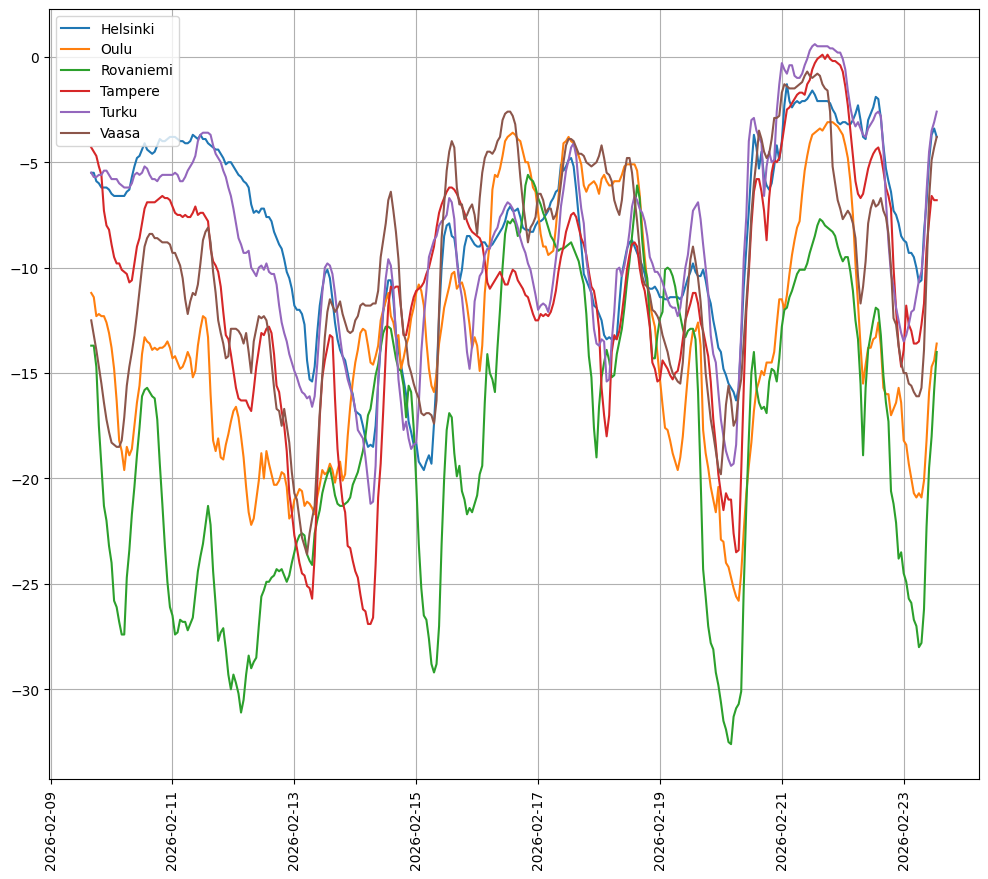

In [13]:
import matplotlib.pyplot as plt

end_t = end_time
seven_days_ago = end_t - timedelta(days = 14)

plt.figure(figsize= (12, 10))

for city in df_merged['city_group'].unique():
    city_df = df_merged[df_merged['city_group'] == city].sort_values('time')
    plot_df = city_df[city_df['time'] >= seven_days_ago]
    plt.plot(plot_df['time'], plot_df['air_temperature'], label = city)





plt.xticks(rotation = 90, )
plt.grid(True)
plt.legend(loc= 'upper left')
plt.show()


In [14]:
df_merged.to_csv("weather_data.csv")